In [1]:
import uuid
import glob
import base64
import requests
import cv2 as cv
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import ImageFile, Image
from matplotlib import pyplot as plt 
from sklearn.metrics import classification_report, confusion_matrix
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
print("Tensorflow version: ", tf.__version__)
print("Pandas version: ", pd.__version__)
print("Numpy version: ", np.__version__)

Tensorflow version:  2.10.0
Pandas version:  2.0.3
Numpy version:  1.24.4


In [3]:
gpus= tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

Num GPUs Available:  0


In [4]:
gpus= tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

Num GPUs Available:  0


In [5]:
def preprocessing_function(image):
    return tf.keras.applications.mobilenet_v2.preprocess_input(image)
    
def load_image_data_generator(
                            train_path: str = 'data/train',
                            valid_path: str = 'data/valid',
                            ):
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                                                                    zoom_range=0.2,
                                                                    shear_range=0.2,
                                                                    rotation_range=20,
                                                                    width_shift_range=0.2,
                                                                    height_shift_range=0.2,
                                                                    horizontal_flip=True,
                                                                    validation_split=0.15,
                                                                    preprocessing_function=preprocessing_function,
                                                                    )
    train_generator = train_datagen.flow_from_directory(
                                                        train_path,
                                                        batch_size=23,
                                                        color_mode='rgb',
                                                        target_size=(224, 224),
                                                        class_mode='categorical',
                                                        subset='training'
                                                        )   

    test_generator = train_datagen.flow_from_directory(
                                                    valid_path,
                                                    batch_size=23,
                                                    color_mode='rgb',
                                                    target_size=(224, 224),
                                                    class_mode='categorical',
                                                    subset='validation'                         
                                                    )   
    return train_generator, test_generator

In [6]:
train_generator, test_generator = load_image_data_generator()

Found 382 images belonging to 22 classes.
Found 51 images belonging to 22 classes.


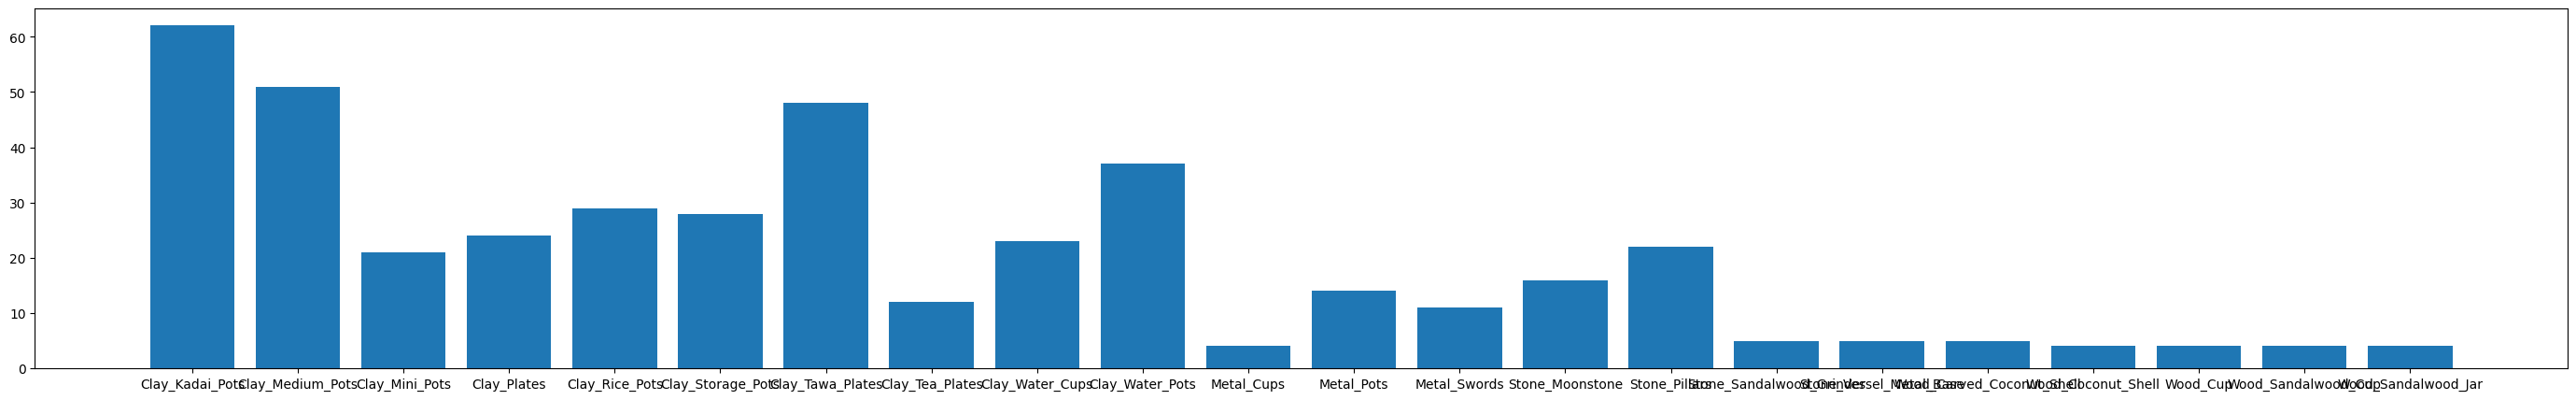

In [7]:

labels = train_generator.classes.tolist() + test_generator.classes.tolist()
value_counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(35, 5))
ax.bar(value_counts[0], value_counts[1])

ax.set_xticks(value_counts[0])

ax.set_xticklabels(list(train_generator.class_indices.keys())[:len(value_counts[0])])

plt.show()


In [8]:
def build_model(input_shape=(224, 224, 3)):
        base_model = tf.keras.applications.MobileNetV2(
                                                        include_top=False,
                                                        weights='imagenet',
                                                        input_shape=input_shape
                                                        )
        base_model.trainable = True

        input_layer = tf.keras.layers.Input(shape=input_shape)
        x = base_model(input_layer)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dense(512, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        x = tf.keras.layers.Dense(256, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        output_layer = tf.keras.layers.Dense(len(train_generator.class_indices), activation='softmax')(x)

        model = tf.keras.Model(
                                inputs=input_layer, 
                                outputs=output_layer
                                )

        model.compile(
                        optimizer='adam', 
                        loss='categorical_crossentropy', 
                        metrics=[
                                tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
                                tf.keras.metrics.Precision(name='precision'),
                                tf.keras.metrics.Recall(name='recall'),
                                tf.keras.metrics.AUC(name='auc')
                                ]
                        )

        return model

In [9]:
model = build_model()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
                                                patience=10,
                                                monitor='val_loss',
                                                restore_best_weights=True
                                                )   

history = model.fit(
                    train_generator, epochs=100,
                    validation_data = test_generator,
                    callbacks = [early_stopping]
                    )

Epoch 1/100
17/17 [==============================] - 94s 5s/step - loss: 2.5387 - accuracy: 0.2880 - precision: 0.7049 - recall: 0.1126 - auc: 0.7665 - val_loss: 2.1929 - val_accuracy: 0.5098 - val_precision: 0.8000 - val_recall: 0.3922 - val_auc: 0.8727
Epoch 2/100
17/17 [==============================] - 64s 4s/step - loss: 1.4027 - accuracy: 0.5916 - precision: 0.8579 - recall: 0.4424 - auc: 0.9389 - val_loss: 3.4732 - val_accuracy: 0.3922 - val_precision: 0.5143 - val_recall: 0.3529 - val_auc: 0.8021
Epoch 3/100
17/17 [==============================] - 64s 4s/step - loss: 0.8416 - accuracy: 0.7487 - precision: 0.9298 - recall: 0.6937 - auc: 0.9763 - val_loss: 5.1339 - val_accuracy: 0.3333 - val_precision: 0.3043 - val_recall: 0.2745 - val_auc: 0.7348
Epoch 4/100
17/17 [==============================] - 64s 4s/step - loss: 0.6036 - accuracy: 0.7984 - precision: 0.9333 - recall: 0.7696 - auc: 0.9868 - val_loss: 10.1865 - val_accuracy: 0.2745 - val_precision: 0.2800 - val_recall: 0.27

In [11]:
model.save('artifacts/pot.h5')

In [12]:
history_cp = history.history.copy()
history_cp['loss'] = np.cumsum(history_cp['loss']) / np.arange(1, len(history_cp['loss']) + 1)
history_cp['val_loss'] = np.cumsum(history_cp['val_loss']) / np.arange(1, len(history_cp['val_loss']) + 1)

history_cp['accuracy'] = np.cumsum(history_cp['accuracy']) / np.arange(1, len(history_cp['accuracy']) + 1)
history_cp['val_accuracy'] = np.cumsum(history_cp['val_accuracy']) / np.arange(1, len(history_cp['val_accuracy']) + 1)

history_cp['precision'] = np.cumsum(history_cp['precision']) / np.arange(1, len(history_cp['precision']) + 1)
history_cp['val_precision'] = np.cumsum(history_cp['val_precision']) / np.arange(1, len(history_cp['val_precision']) + 1)

history_cp['recall'] = np.cumsum(history_cp['recall']) / np.arange(1, len(history_cp['recall']) + 1)
history_cp['val_recall'] = np.cumsum(history_cp['val_recall']) / np.arange(1, len(history_cp['val_recall']) + 1)

history_cp['auc'] = np.cumsum(history_cp['auc']) / np.arange(1, len(history_cp['auc']) + 1)
history_cp['val_auc'] = np.cumsum(history_cp['val_auc']) / np.arange(1, len(history_cp['val_auc']) + 1)

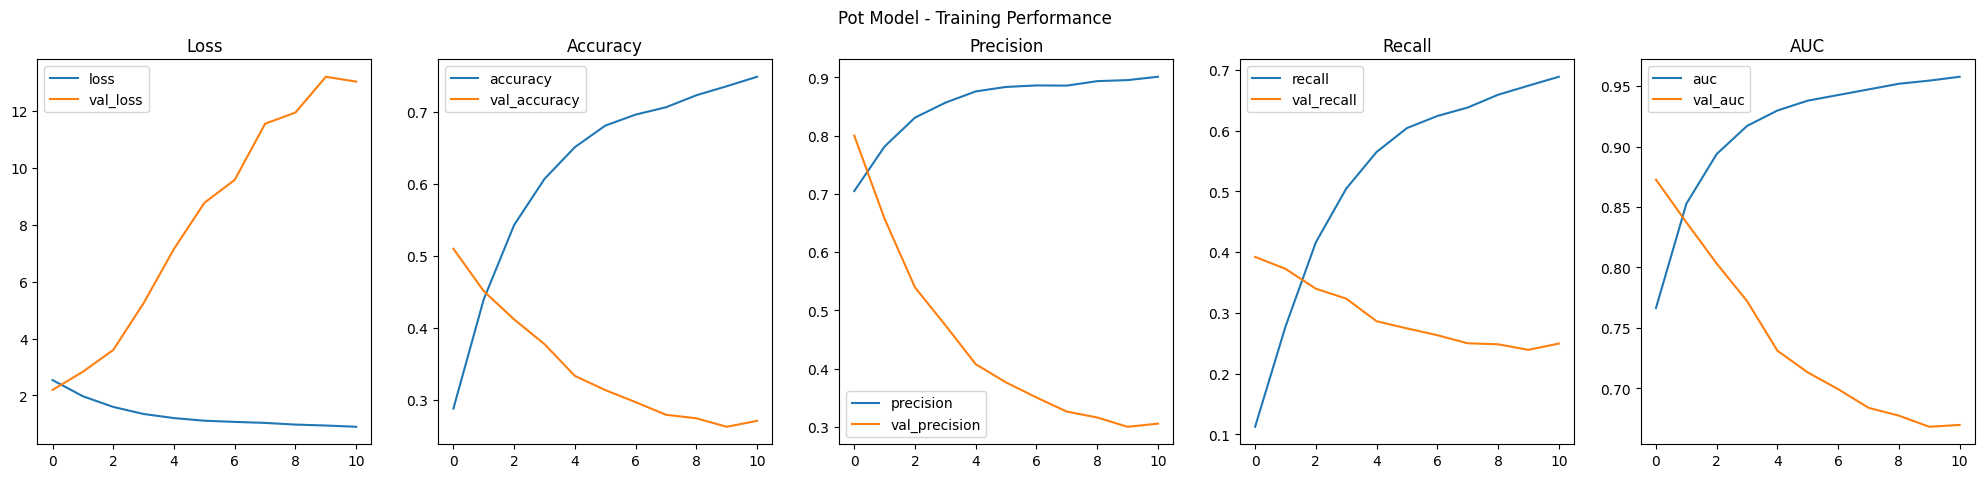

In [13]:
plt.figure(figsize=(25, 5))
plt.subplot(1, 5, 1)
plt.plot(history_cp['loss'], label='loss')
plt.plot(history_cp['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 5, 2)
plt.plot(history_cp['accuracy'], label='accuracy')
plt.plot(history_cp['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 5, 3)
plt.plot(history_cp['precision'], label='precision')
plt.plot(history_cp['val_precision'], label='val_precision')
plt.legend()
plt.title('Precision')

plt.subplot(1, 5, 4)
plt.plot(history_cp['recall'], label='recall')
plt.plot(history_cp['val_recall'], label='val_recall')
plt.legend()
plt.title('Recall')

plt.subplot(1, 5, 5)
plt.plot(history_cp['auc'], label='auc')
plt.plot(history_cp['val_auc'], label='val_auc')
plt.legend()
plt.title('AUC')

plt.suptitle('Pot Model - Training Performance')
plt.show()

### Evaluation

In [14]:
import cv2 as cv
import numpy as np
import seaborn as sns
import tensorflow as tf
from PIL import ImageFile
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [15]:
model_disease = tf.keras.models.load_model('artifacts/pot.h5')
model_disease.compile(
                optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=[
                        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
                        tf.keras.metrics.Precision(name='precision'),
                        tf.keras.metrics.Recall(name='recall'),
                        tf.keras.metrics.AUC(name='auc')
                        ]
                )

In [16]:
def preprocessing_function(image):
    return tf.keras.applications.xception.preprocess_input(image)
    
def inference_animal(image_path):
    image = cv.imread(image_path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    image = cv.resize(image, (224, 224))
    image = np.expand_dims(image, axis=0)
    image = preprocessing_function(image)
    pred = model_disease.predict(
                                image,
                                verbose=0
                                ).squeeze()
    label = pred.argmax()
    return label

In [17]:
eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                                                                preprocessing_function=preprocessing_function
                                                                )
eval_generator = eval_datagen.flow_from_directory(
                                                'data/valid',
                                                batch_size=32,
                                                color_mode='rgb',
                                                target_size=(224, 224),
                                                class_mode='categorical',
                                                shuffle=False      
                                                )   


Found 417 images belonging to 22 classes.


In [18]:
Ytest = eval_generator.classes
Ptest = model_disease.predict(eval_generator)
Ptest = np.argmax(Ptest, axis=1)


14/14 [==============================] - 63s 4s/step


In [19]:
class_dict = eval_generator.class_indices
class_dict_rev = {v: k for k, v in class_dict.items()}
class_dict_rev

{0: 'Clay_Kadai_Pots',
 1: 'Clay_Medium_Pots',
 2: 'Clay_Mini_Pots',
 3: 'Clay_Plates',
 4: 'Clay_Rice_Pots',
 5: 'Clay_Storage_Pots',
 6: 'Clay_Tawa_Plates',
 7: 'Clay_Tea_Plates',
 8: 'Clay_Water_Cups',
 9: 'Clay_Water_Pots',
 10: 'Metal_Cups',
 11: 'Metal_Pots',
 12: 'Metal_Swords',
 13: 'Stone_Moonstone',
 14: 'Stone_Pillars',
 15: 'Stone_Sandalwood_Grinder',
 16: 'Stone_Vessel_Metal_Base',
 17: 'Wood_Carved_Coconut_Shell',
 18: 'Wood_Coconut_Shell',
 19: 'Wood_Cup',
 20: 'Wood_Sandalwood_Cup',
 21: 'Wood_Sandalwood_Jar'}

In [20]:
num_classes = len(np.unique(Ytest))

target_names = list(class_dict.keys())

if len(target_names) != num_classes:
    print(f"Warning: Mismatch in number of target names ({len(target_names)}) and actual unique class labels ({num_classes})")
    target_names = target_names[:num_classes]

clf_report = classification_report(
                                    Ytest,
                                    Ptest,
                                    target_names=target_names 
                                    )   

cm = confusion_matrix(Ytest, Ptest)

c:\Users\akidu\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\akidu\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\akidu\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [21]:
print("############### Classification Report ###############")
print(clf_report)

############### Classification Report ###############
                           precision    recall  f1-score   support

          Clay_Kadai_Pots       0.97      1.00      0.98        62
         Clay_Medium_Pots       0.42      0.98      0.59        51
           Clay_Mini_Pots       0.00      0.00      0.00        21
              Clay_Plates       0.00      0.00      0.00        24
           Clay_Rice_Pots       1.00      0.03      0.07        29
        Clay_Storage_Pots       0.29      0.93      0.44        28
         Clay_Tawa_Plates       0.92      0.48      0.63        48
          Clay_Tea_Plates       0.00      0.00      0.00        12
          Clay_Water_Cups       0.00      0.00      0.00        23
          Clay_Water_Pots       0.28      0.81      0.42        37
               Metal_Cups       0.00      0.00      0.00         4
               Metal_Pots       0.00      0.00      0.00        14
             Metal_Swords       0.00      0.00      0.00        11
       

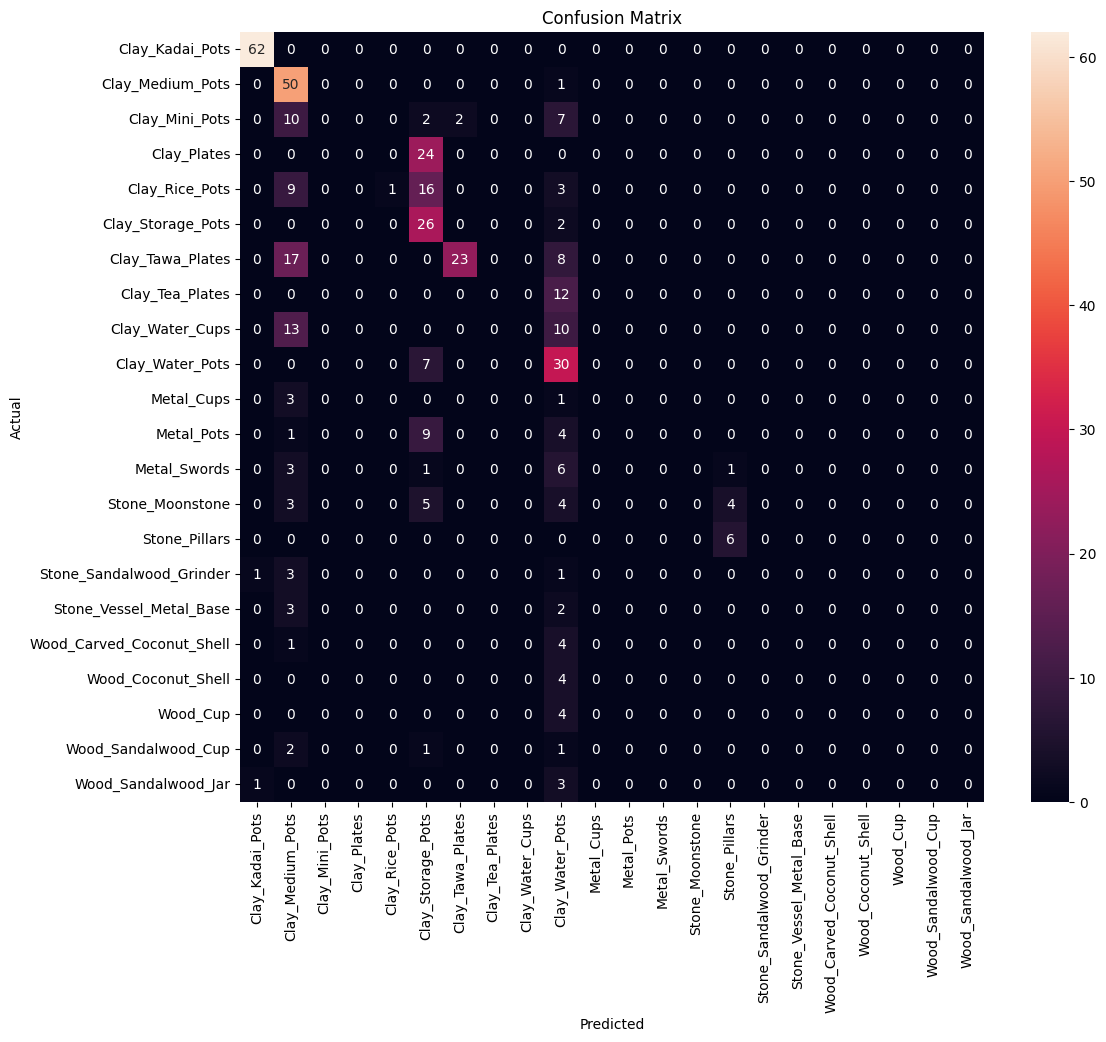

In [22]:
plt.figure(figsize=(12, 10))
sns.heatmap(
            cm, 
            fmt='d', 
            annot=True, 
            xticklabels=list(class_dict.keys()), 
            yticklabels=list(class_dict.keys())
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Inference

In [25]:
import os
import time
import torch
import cv2 as cv
import numpy as np
from PIL import Image
import tensorflow as tf

In [26]:
model_disease = tf.keras.models.load_model('artifacts/pot.h5')
model_disease.compile(
                optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=[
                        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
                        tf.keras.metrics.Precision(name='precision'),
                        tf.keras.metrics.Recall(name='recall'),
                        tf.keras.metrics.AUC(name='auc')
                        ]
                )

In [28]:
def inference_disease(
                    image_path,
                    class_dict = {
                                0: 'Clay_Kadai_Pots',
                                1: 'Clay_Medium_Pots',
                                2: 'Clay_Mini_Pots',
                                3: 'Clay_Plates',
                                4: 'Clay_Rice_Pots',
                                5: 'Clay_Storage_Pots',
                                6: 'Clay_Tawa_Plates',
                                7: 'Clay_Tea_Plates',
                                8: 'Clay_Water_Cups',
                                9: 'Clay_Water_Pots',
                                10: 'Metal_Cups',
                                11: 'Metal_Pots',
                                12: 'Metal_Swords',
                                13: 'Stone_Moonstone',
                                14: 'Stone_Pillars',
                                15: 'Stone_Sandalwood_Grinder',
                                16: 'Stone_Vessel_Metal_Base',
                                17: 'Wood_Carved_Coconut_Shell',
                                18: 'Wood_Coconut_Shell',
                                19: 'Wood_Cup',
                                20: 'Wood_Sandalwood_Cup',
                                21: 'Wood_Sandalwood_Jar'
                                }
                    ):
        image = cv.imread(image_path)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        image = cv.resize(image, (224, 224))
        image = np.expand_dims(image, axis=0)
        image = tf.keras.applications.xception.preprocess_input(image)
        pred = model_disease.predict(
                                    image,
                                    verbose=0
                                    ).squeeze()
        label = int(pred.argmax())
        return class_dict[label]

In [29]:
inference_disease('data/valid/Clay_Kadai_Pots/IMG_20180810_114420 - Copy.jpg')

'Clay_Kadai_Pots'

inference Count Test Classes

In [30]:
import os
import time
import cv2 as cv
import numpy as np
import tensorflow as tf

model_disease = tf.keras.models.load_model('artifacts/pot.h5')
model_disease.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

def inference_disease(image_path, class_dict):
  
    image = cv.imread(image_path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    image = cv.resize(image, (224, 224))  
    image = np.expand_dims(image, axis=0)  
    image = tf.keras.applications.xception.preprocess_input(image) 

    
    pred = model_disease.predict(image, verbose=0).squeeze()
    label = int(pred.argmax()) 
    return class_dict[label]  


root_folder = 'data/valid'


class_folders = os.listdir(root_folder)
class_dict = {index: folder_name for index, folder_name in enumerate(class_folders)}
class_counts = {class_name: 0 for class_name in class_folders}


for class_name in class_folders:
    class_folder_path = os.path.join(root_folder, class_name)
    
   
    if os.path.isdir(class_folder_path):
       
        files = os.listdir(class_folder_path)
       
        image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')
        image_files = [file for file in files if file.lower().endswith(image_extensions)]
        
        
        for image in image_files:
            image_path = os.path.join(class_folder_path, image)  
            predicted_class = inference_disease(image_path, class_dict) 
            # print(f"Image: {image}, Predicted Class: {predicted_class}")  
            
            if predicted_class == class_name:
                class_counts[class_name] += 1
            

for class_name, count in class_counts.items():
    print(f"{class_name} count: {count}")


Clay_Kadai_Pots count: 62
Clay_Medium_Pots count: 51
Clay_Mini_Pots count: 0
Clay_Plates count: 8
Clay_Rice_Pots count: 0
Clay_Storage_Pots count: 24
Clay_Tawa_Plates count: 0
Clay_Tea_Plates count: 0
Clay_Water_Cups count: 0
Clay_Water_Pots count: 0
Metal_Cups count: 0
Metal_Pots count: 0
Metal_Swords count: 0
Stone_Moonstone count: 0
Stone_Pillars count: 1
Stone_Sandalwood_Grinder count: 0
Stone_Vessel_Metal_Base count: 0
Wood_Carved_Coconut_Shell count: 0
Wood_Coconut_Shell count: 0
Wood_Cup count: 0
Wood_Sandalwood_Cup count: 0
Wood_Sandalwood_Jar count: 0
